In [1]:
import os
import sys
import matplotlib.pyplot as plt
import torch
from sklearn.metrics import confusion_matrix, f1_score, classification_report
import numpy as np
PROJECT_ROOT = os.path.abspath("..") 
sys.path.append(PROJECT_ROOT)

In [ ]:

from dataset.otto_final import TraceOttoDataset
from model.trace import TRACE
from utils.SplitData import split_data_Train_Val_Test
from utils.feature_engineering import get_between_features, get_elapsed_feature
from utils.plot_confussion_matrix import plot_confusion_matrix
from utils.training_utils import update_binary_metrics
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")



In [ ]:
trace_model = TRACE(
    num_embeddings_aid=1855603,
    num_embeddings_event_type=4,
    embedding_dim=32,
    num_classes=1
).to(device)

checkpoint = torch.load("Model_TRACE_ATC_FinalVersion_SingleTask.pt", weights_only=False, map_location=device)

trace_model.load_state_dict(checkpoint["model_state_dict"])
best_thr = checkpoint["best_global_threshold"]
if torch.is_tensor(best_thr):
    best_thr = best_thr.item()
elif isinstance(best_thr, np.ndarray):
    best_thr = best_thr.item()

trace_model.eval()
print(f"Model Charge with best threshold: {best_thr:.4f}")

Modelo cargado con éxito. Umbral óptimo: 0.5300


In [5]:
dataset_processed  = TraceOttoDataset(
    file_name='../train.jsonl',
    input_seq_len=64,
    min_timestamps_per_sample=16,
)

In [ ]:
train_loader, validation_loader, test_loader = split_data_Train_Val_Test(dataset_processed, batch_size=128)


print(len(train_loader.dataset))
print(len(validation_loader.dataset))
print(len(test_loader.dataset))


2531821
316477
316479


Test loss: 0.5589
Test accuracy: 0.7067
F1 Score: 0.6373166929115398
Optimum Threshold 0.5300
Confusion Matrix:
 [[142108  69905]
 [ 22914  81552]]

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.67      0.75    212013
           1       0.54      0.78      0.64    104466

    accuracy                           0.71    316479
   macro avg       0.70      0.73      0.70    316479
weighted avg       0.75      0.71      0.72    316479



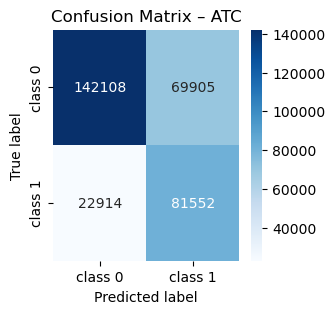

In [ ]:
trace_model.eval()
criterion = torch.nn.BCEWithLogitsLoss()
test_loss = 0.0
test_correct = 0
test_total = 0

y_true = []
y_pred = []
with torch.no_grad():
    for inputs_test, targets_test in test_loader:
        label_test_task = targets_test["ATC"].unsqueeze(1).to(device)

        inputs_test = {k: v.to(device) for k, v in inputs_test.items()}

        delta_elapsed = get_elapsed_feature(inputs_test["timestamps"]).to(device)
        delta_between = get_between_features(inputs_test["timestamps"]).to(device)

        logits = trace_model(
            inputs_test["aid"],
            inputs_test["type"],
            delta_elapsed,
            delta_between
        )

        loss = criterion(logits, label_test_task.float())
        test_loss += loss.item()
        test_correct, test_total = update_binary_metrics(logits, targets_test, test_correct, test_total, y_true, y_pred, best_thr)


test_loss /= len(test_loader)
test_accuracy = test_correct / max(test_total, 1)


y_true = torch.cat(y_true).numpy().astype(int).ravel()
y_pred = torch.cat(y_pred).numpy().astype(int).ravel()

f1 = f1_score(y_true, y_pred)

cm = confusion_matrix(y_true, y_pred)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")
print(f"F1 Score: {f1}")
print(f"Optimum Threshold {best_thr:.4f}")
print("Confusion Matrix:\n", cm)
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=["0", "1"]))


fig = plot_confusion_matrix(
    cm,
    name_task="ATC",
    name_classes=["class 0", "class 1"]
)
plt.show()
plt.close(fig)
